# Question 3: Advanced Player Playstyle Archetype Clustering

This notebook builds a more sophisticated unsupervised model for Question 3. It combines engineered numeric opening features with TF-IDF representations of each player's favorite openings, compresses the high-dimensional text signal, and trains a probabilistic clustering model to discover player playstyle archetypes.


## Why This Is More Advanced
1. It uses both structured chess features and text-style opening repertoire signals.
2. It reduces high-dimensional opening vocabulary with `TruncatedSVD`.
3. It trains a probabilistic `GaussianMixture` model instead of plain KMeans.
4. It compares multiple cluster counts and covariance structures using both BIC and silhouette score.
5. It outputs soft-clustering probabilities so each player's archetype assignment has a confidence level.


In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [2]:
DATA_PATH = Path('/Users/phamhoanghai/Ureca/dataset/final_data')
OUTPUT_DIR = Path('/Users/phamhoanghai/Ureca/Question_three/advanced_output')
PLOT_DIR = Path('/Users/phamhoanghai/Ureca/Question_three/advanced_plots')

MIN_GAMES_PER_PLAYER = 20
TOP_N_FAVORITE_OPENINGS = 5
RANDOM_STATE = 42
N_TEXT_COMPONENTS = 25
CANDIDATE_K = range(4, 9)
COVARIANCE_TYPES = ['full', 'tied', 'diag', 'spherical']

NUMERIC_FEATURE_COLUMNS = [
    'games_played',
    'avg_elo',
    'mean_score',
    'opening_diversity',
    'favorite_opening_share',
    'favorite_openings_coverage',
    'family_closed_share',
    'family_flank_share',
    'family_indian_share',
    'family_open_share',
    'family_semi_open_share',
    'eco_a_share',
    'eco_b_share',
    'eco_c_share',
    'eco_d_share',
    'eco_e_share',
    'attackish_share',
    'defensive_share',
    'positional_share',
    'hypermodern_share',
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH)
print(DATA_PATH.exists())


/Users/phamhoanghai/Ureca/dataset/final_data
True


In [3]:
usecols = [
    'GameID', 'White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric',
    'ECO', 'Opening', 'OpeningFamily', 'NumericResult'
]

raw_df = pd.read_csv(DATA_PATH, usecols=usecols)
raw_df = raw_df.dropna(subset=['White', 'Black', 'WhiteEloNumeric', 'BlackEloNumeric', 'Opening', 'OpeningFamily', 'ECO']).copy()
print('Loaded shape:', raw_df.shape)
raw_df.head()


Loaded shape: (1111082, 9)


,GameID,White,Black,WhiteEloNumeric,BlackEloNumeric,ECO,Opening,NumericResult,OpeningFamily
0,1,sisy,lpaulmp,1645.0,1449.0,D31,Queen's Gambit Declined: Queen's Knight Variation,1.0,Closed and Semi-Closed
1,2,capablanca1950,ftri67,1603.0,1672.0,C00,French Defense,0.0,Open Games and Semi-Open
2,3,daamien,mike81,1166.0,1280.0,D00,Queen's Pawn Game: Steinitz Countergambit,1.0,Closed and Semi-Closed
3,4,yaavarmo,JACKELCALVO,1494.0,1449.0,C00,French Defense: Normal Variation,1.0,Open Games and Semi-Open
4,5,albinofrenchy,galita,1256.0,1285.0,D53,Queen's Gambit Declined: 4.Bg5 Be7,1.0,Closed and Semi-Closed


## Build Player-Perspective Dataset
Each original game becomes two player records, one from White's perspective and one from Black's perspective. That lets us model each player's opening identity directly.


In [4]:
white_rows = raw_df.rename(columns={'White': 'player', 'WhiteEloNumeric': 'player_elo'})[[
    'GameID', 'player', 'player_elo', 'Opening', 'OpeningFamily', 'ECO', 'NumericResult'
]].copy()
white_rows['perspective_score'] = white_rows['NumericResult']

black_rows = raw_df.rename(columns={'Black': 'player', 'BlackEloNumeric': 'player_elo'})[[
    'GameID', 'player', 'player_elo', 'Opening', 'OpeningFamily', 'ECO', 'NumericResult'
]].copy()
black_rows['perspective_score'] = 1 - black_rows['NumericResult']

player_games = pd.concat([white_rows, black_rows], ignore_index=True)
player_games['ECOGroup'] = player_games['ECO'].astype(str).str[0].str.upper()

print('Player-perspective shape:', player_games.shape)
print('Unique players:', player_games['player'].nunique())
player_games.head()


Player-perspective shape: (2222164, 9)
Unique players: 30026


,GameID,player,player_elo,Opening,OpeningFamily,ECO,NumericResult,perspective_score,ECOGroup
0,1,sisy,1645.0,Queen's Gambit Declined: Queen's Knight Variation,Closed and Semi-Closed,D31,1.0,1.0,D
1,2,capablanca1950,1603.0,French Defense,Open Games and Semi-Open,C00,0.0,0.0,C
2,3,daamien,1166.0,Queen's Pawn Game: Steinitz Countergambit,Closed and Semi-Closed,D00,1.0,1.0,D
3,4,yaavarmo,1494.0,French Defense: Normal Variation,Open Games and Semi-Open,C00,1.0,1.0,C
4,5,albinofrenchy,1256.0,Queen's Gambit Declined: 4.Bg5 Be7,Closed and Semi-Closed,D53,1.0,1.0,D


In [5]:
def weighted_keyword_share(opening_counts: pd.Series, keywords: tuple[str, ...]) -> float:
    total = opening_counts.sum()
    if total == 0:
        return 0.0
    mask = opening_counts.index.to_series().str.lower().apply(
        lambda name: any(keyword in name for keyword in keywords)
    )
    return float(opening_counts[mask.values].sum() / total)

eligible = player_games.groupby('player').filter(lambda frame: len(frame) >= MIN_GAMES_PER_PLAYER).copy()
print('Eligible rows:', eligible.shape)
print('Eligible players:', eligible['player'].nunique())


Eligible rows: (2132503, 9)
Eligible players: 12888


In [6]:
records = []
favorite_rows = []
opening_corpus_rows = []

for player, frame in eligible.groupby('player', sort=False):
    opening_counts = frame['Opening'].value_counts()
    favorite_counts = opening_counts.head(TOP_N_FAVORITE_OPENINGS)
    favorite_openings = favorite_counts.index.tolist()
    favorite_frame = frame[frame['Opening'].isin(favorite_openings)].copy()

    total_games = len(frame)
    favorite_total_games = int(favorite_counts.sum())

    family_share = (
        favorite_frame['OpeningFamily']
        .value_counts(normalize=True)
        .reindex([
            'Closed and Semi-Closed',
            'Flank Openings',
            'Indian Defenses',
            'Open Games and Semi-Open',
            'Semi-Open Defenses',
        ], fill_value=0.0)
    )

    eco_share = (
        favorite_frame['ECOGroup']
        .value_counts(normalize=True)
        .reindex(list('ABCDE'), fill_value=0.0)
    )

    top_opening = favorite_counts.index[0]
    top_opening_games = int(favorite_counts.iloc[0])

    weighted_tokens = []
    for opening_name, count in favorite_counts.items():
        clean_name = opening_name.replace(':', ' ').replace(',', ' ')
        weighted_tokens.extend([clean_name] * int(count))
        favorite_rows.append({
            'player': player,
            'opening': opening_name,
            'games': int(count),
            'share_within_player': float(count / total_games),
        })

    opening_corpus_rows.append({
        'player': player,
        'opening_corpus': ' ; '.join(weighted_tokens)
    })

    records.append({
        'player': player,
        'games_played': total_games,
        'avg_elo': float(frame['player_elo'].mean()),
        'mean_score': float(frame['perspective_score'].mean()),
        'opening_diversity': int(frame['Opening'].nunique()),
        'favorite_opening': top_opening,
        'favorite_opening_games': top_opening_games,
        'favorite_opening_share': float(top_opening_games / total_games),
        'favorite_openings_coverage': float(favorite_total_games / total_games),
        'family_closed_share': float(family_share['Closed and Semi-Closed']),
        'family_flank_share': float(family_share['Flank Openings']),
        'family_indian_share': float(family_share['Indian Defenses']),
        'family_open_share': float(family_share['Open Games and Semi-Open']),
        'family_semi_open_share': float(family_share['Semi-Open Defenses']),
        'eco_a_share': float(eco_share['A']),
        'eco_b_share': float(eco_share['B']),
        'eco_c_share': float(eco_share['C']),
        'eco_d_share': float(eco_share['D']),
        'eco_e_share': float(eco_share['E']),
        'attackish_share': weighted_keyword_share(favorite_counts, ('attack', 'gambit', 'sacrifice', 'storm')),
        'defensive_share': weighted_keyword_share(favorite_counts, ('defense', 'defence', 'declined')),
        'positional_share': weighted_keyword_share(favorite_counts, ('system', 'london', 'english', 'reti', 'catalan', "queen's gambit", 'slav', 'caro-kann')),
        'hypermodern_share': weighted_keyword_share(favorite_counts, ('indian', 'modern', 'pirc', 'reti', 'english', 'bird', 'owen', 'larsen', 'grunfeld', 'benoni')),
    })

player_profiles = pd.DataFrame(records)
favorite_detail = pd.DataFrame(favorite_rows)
opening_corpus_df = pd.DataFrame(opening_corpus_rows)

player_profiles = player_profiles.merge(opening_corpus_df, on='player', how='left')
print('Player profiles:', player_profiles.shape)
player_profiles.head()


Player profiles: (12888, 24)


,player,games_played,avg_elo,mean_score,opening_diversity,favorite_opening,favorite_opening_games,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share,opening_corpus
0,sisy,683,1733.551977,0.580527,104,Old Benoni Defense,56,0.081991,0.259151,0.333333,0.463277,0.0,0.000000,0.203390,0.463277,0.203390,0.000000,0.333333,0.0,0.152542,0.853107,0.333333,0.316384,Old Benoni Defense ; Old Benoni Defense ; Old ...
1,capablanca1950,490,1649.089796,0.497959,181,Caro-Kann Defense,32,0.065306,0.189796,0.000000,0.000000,0.0,0.268817,0.731183,0.000000,0.731183,0.268817,0.000000,0.0,0.000000,0.881720,0.731183,0.000000,Caro-Kann Defense ; Caro-Kann Defense ; Caro-K...
2,daamien,31,1447.645161,0.596774,16,Queen's Pawn Game: Mason Attack,5,0.161290,0.548387,0.294118,0.176471,0.0,0.000000,0.529412,0.176471,0.529412,0.000000,0.294118,0.0,0.294118,0.705882,0.529412,0.000000,Queen's Pawn Game Mason Attack ; Queen's Pawn...
3,yaavarmo,216,1563.268519,0.449074,82,King's Pawn Game,31,0.143519,0.328704,0.000000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.563380,0.000000,0.000000,King's Pawn Game ; King's Pawn Game ; King's P...
4,albinofrenchy,236,1513.588983,0.461864,113,Sicilian Defense: Old Sicilian,12,0.050847,0.186441,0.522727,0.000000,0.0,0.000000,0.477273,0.000000,0.477273,0.000000,0.522727,0.0,0.545455,0.818182,0.522727,0.000000,Sicilian Defense Old Sicilian ; Sicilian Defe...


## Build Hybrid Feature Space
This notebook uses two feature blocks:
- Numeric repertoire and style statistics
- TF-IDF text representation of favorite openings

The TF-IDF block is reduced with `TruncatedSVD` so the Gaussian mixture model can train on a dense, lower-dimensional embedding.


In [7]:
numeric_scaler = StandardScaler()
X_numeric = numeric_scaler.fit_transform(player_profiles[NUMERIC_FEATURE_COLUMNS])

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5,
    max_features=1200,
)
X_text_tfidf = vectorizer.fit_transform(player_profiles['opening_corpus'])

n_components = min(N_TEXT_COMPONENTS, max(2, X_text_tfidf.shape[1] - 1))
svd = TruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)
X_text = svd.fit_transform(X_text_tfidf)
X_text = StandardScaler().fit_transform(X_text)

X_hybrid = np.hstack([X_numeric, X_text])

print('Numeric feature shape:', X_numeric.shape)
print('TF-IDF matrix shape:', X_text_tfidf.shape)
print('Reduced text shape:', X_text.shape)
print('Hybrid shape:', X_hybrid.shape)


Numeric feature shape: (12888, 20)
TF-IDF matrix shape: (12888, 1200)
Reduced text shape: (12888, 25)
Hybrid shape: (12888, 45)


## Train The Advanced Clustering Model
We evaluate several Gaussian mixture configurations. Lower BIC is better for probabilistic model fit, while higher silhouette score indicates cleaner separation.


In [8]:
search_results = []
models = {}

for covariance_type in COVARIANCE_TYPES:
    for k in CANDIDATE_K:
        gmm = GaussianMixture(
            n_components=k,
            covariance_type=covariance_type,
            random_state=RANDOM_STATE,
            n_init=3,
            reg_covar=1e-6,
        )
        labels = gmm.fit_predict(X_hybrid)
        bic = gmm.bic(X_hybrid)
        sil = silhouette_score(X_hybrid, labels)
        search_results.append({
            'covariance_type': covariance_type,
            'k': k,
            'bic': float(bic),
            'silhouette_score': float(sil),
        })
        models[(covariance_type, k)] = gmm

model_search_df = pd.DataFrame(search_results).sort_values(['bic', 'silhouette_score'], ascending=[True, False]).reset_index(drop=True)
model_search_df.head(12)


,covariance_type,k,bic,silhouette_score
0,full,8,-339070.645827,0.003800
1,full,7,-305386.308004,-0.000811
2,full,6,-298681.331483,0.013275
3,full,5,-250769.268834,0.014023
4,full,4,-182824.261496,0.027043
5,tied,8,249554.154265,0.073876
6,tied,7,253875.630864,0.071882
7,tied,6,275252.567420,0.063719
8,tied,5,287514.842187,0.054403
9,tied,4,292206.962510,0.078194


In [9]:
best_row = model_search_df.iloc[0]
best_covariance = best_row['covariance_type']
best_k = int(best_row['k'])

best_model = models[(best_covariance, best_k)]
cluster_labels = best_model.predict(X_hybrid)
cluster_probs = best_model.predict_proba(X_hybrid)
assignment_confidence = cluster_probs.max(axis=1)

player_profiles = player_profiles.copy()
player_profiles['cluster_id'] = cluster_labels
player_profiles['assignment_confidence'] = assignment_confidence

print('Best covariance:', best_covariance)
print('Best k:', best_k)
print('Best BIC:', round(float(best_row['bic']), 2))
print('Best silhouette:', round(float(best_row['silhouette_score']), 4))


Best covariance: full
Best k: 8
Best BIC: -339070.65
Best silhouette: 0.0038


In [10]:
cluster_feature_means = (
    player_profiles.groupby('cluster_id', as_index=False)[NUMERIC_FEATURE_COLUMNS]
    .mean()
)

cluster_sizes = player_profiles['cluster_id'].value_counts().sort_index()
cluster_feature_means['players'] = cluster_feature_means['cluster_id'].map(cluster_sizes)
cluster_feature_means


,cluster_id,games_played,avg_elo,mean_score,opening_diversity,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share,players
0,0,154.729766,1687.122231,0.523538,60.416367,0.115082,0.349835,0.252614,0.303100,0.000000,0.075532,0.368754,0.303100,0.368754,0.075532,0.252614,0.000000,0.241346,0.671504,0.326968,0.242019,2224
1,1,147.690806,1584.930404,0.492506,64.876733,0.093092,0.297741,0.150650,0.060683,0.000000,0.595464,0.193202,0.060683,0.193202,0.595464,0.150650,0.000000,0.221142,0.643646,0.130261,0.046476,1947
2,2,162.448798,1593.326647,0.502923,64.606857,0.109750,0.333636,0.000000,0.071284,0.000000,0.477710,0.451005,0.071284,0.451005,0.477710,0.000000,0.000000,0.239921,0.780369,0.018152,0.082707,2246
3,3,111.477585,1656.842183,0.500786,54.531565,0.103327,0.317649,0.137062,0.230764,0.081084,0.287189,0.263902,0.230764,0.263902,0.287189,0.137062,0.081084,0.199049,0.639839,0.203617,0.298311,1093
4,4,108.882836,1468.332690,0.459751,54.420896,0.103919,0.317777,0.090224,0.069661,0.000000,0.617854,0.222261,0.069661,0.222261,0.617854,0.090224,0.000000,0.195002,0.549083,0.049549,0.053431,1340
5,5,248.427517,1614.566184,0.480363,72.320805,0.121106,0.346036,0.098987,0.318090,0.000000,0.226032,0.356891,0.318090,0.356891,0.226032,0.098987,0.000000,0.151503,0.632978,0.160459,0.273434,1490
6,6,142.970129,1438.683810,0.430092,43.822811,0.193276,0.473974,0.195593,0.225667,0.000000,0.414424,0.164316,0.225667,0.164316,0.414424,0.195593,0.000000,0.166059,0.459470,0.011001,0.035211,1473
7,7,267.413953,1608.167148,0.474393,54.093023,0.251288,0.546047,0.000000,0.616902,0.000000,0.071158,0.311940,0.616902,0.311940,0.071158,0.000000,0.000000,0.107834,0.470821,0.077780,0.358047,1075


In [11]:
def infer_cluster_label(center: pd.Series) -> str:
    family_scores = {
        'closed': center['family_closed_share'],
        'flank': center['family_flank_share'],
        'indian': center['family_indian_share'],
        'open': center['family_open_share'],
        'semi_open': center['family_semi_open_share'],
    }
    dominant_family = max(family_scores, key=family_scores.get)

    if dominant_family == 'flank' and center['hypermodern_share'] >= 0.20:
        return 'Hypermodern Strategists'
    if dominant_family == 'indian':
        return 'Indian Defense Specialists'
    if dominant_family == 'closed':
        return 'Positional Defenders'
    if dominant_family == 'semi_open' and center['defensive_share'] >= 0.45:
        return 'Counterpunching Defenders'
    if dominant_family == 'open' and center['attackish_share'] >= 0.15:
        return 'Aggressive Attackers'
    if center['favorite_opening_share'] >= 0.20:
        return 'Opening Loyalists'
    return 'Flexible Universalists'

cluster_feature_means['archetype'] = cluster_feature_means.apply(infer_cluster_label, axis=1)
label_map = cluster_feature_means.set_index('cluster_id')['archetype'].to_dict()
player_profiles['archetype'] = player_profiles['cluster_id'].map(label_map)

cluster_feature_means.sort_values('cluster_id')


,cluster_id,games_played,avg_elo,mean_score,opening_diversity,favorite_opening_share,favorite_openings_coverage,family_closed_share,family_flank_share,family_indian_share,family_open_share,family_semi_open_share,eco_a_share,eco_b_share,eco_c_share,eco_d_share,eco_e_share,attackish_share,defensive_share,positional_share,hypermodern_share,players,archetype
0,0,154.729766,1687.122231,0.523538,60.416367,0.115082,0.349835,0.252614,0.303100,0.000000,0.075532,0.368754,0.303100,0.368754,0.075532,0.252614,0.000000,0.241346,0.671504,0.326968,0.242019,2224,Counterpunching Defenders
1,1,147.690806,1584.930404,0.492506,64.876733,0.093092,0.297741,0.150650,0.060683,0.000000,0.595464,0.193202,0.060683,0.193202,0.595464,0.150650,0.000000,0.221142,0.643646,0.130261,0.046476,1947,Aggressive Attackers
2,2,162.448798,1593.326647,0.502923,64.606857,0.109750,0.333636,0.000000,0.071284,0.000000,0.477710,0.451005,0.071284,0.451005,0.477710,0.000000,0.000000,0.239921,0.780369,0.018152,0.082707,2246,Aggressive Attackers
3,3,111.477585,1656.842183,0.500786,54.531565,0.103327,0.317649,0.137062,0.230764,0.081084,0.287189,0.263902,0.230764,0.263902,0.287189,0.137062,0.081084,0.199049,0.639839,0.203617,0.298311,1093,Aggressive Attackers
4,4,108.882836,1468.332690,0.459751,54.420896,0.103919,0.317777,0.090224,0.069661,0.000000,0.617854,0.222261,0.069661,0.222261,0.617854,0.090224,0.000000,0.195002,0.549083,0.049549,0.053431,1340,Aggressive Attackers
5,5,248.427517,1614.566184,0.480363,72.320805,0.121106,0.346036,0.098987,0.318090,0.000000,0.226032,0.356891,0.318090,0.356891,0.226032,0.098987,0.000000,0.151503,0.632978,0.160459,0.273434,1490,Counterpunching Defenders
6,6,142.970129,1438.683810,0.430092,43.822811,0.193276,0.473974,0.195593,0.225667,0.000000,0.414424,0.164316,0.225667,0.164316,0.414424,0.195593,0.000000,0.166059,0.459470,0.011001,0.035211,1473,Aggressive Attackers
7,7,267.413953,1608.167148,0.474393,54.093023,0.251288,0.546047,0.000000,0.616902,0.000000,0.071158,0.311940,0.616902,0.311940,0.071158,0.000000,0.000000,0.107834,0.470821,0.077780,0.358047,1075,Hypermodern Strategists


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_hybrid)
player_profiles['pca_1'] = coords[:, 0]
player_profiles['pca_2'] = coords[:, 1]

cluster_summary = (
    player_profiles.groupby(['cluster_id', 'archetype'], as_index=False)
    .agg(
        players=('player', 'count'),
        mean_games=('games_played', 'mean'),
        mean_elo=('avg_elo', 'mean'),
        mean_opening_diversity=('opening_diversity', 'mean'),
        mean_favorite_share=('favorite_opening_share', 'mean'),
        mean_top5_coverage=('favorite_openings_coverage', 'mean'),
        mean_score=('mean_score', 'mean'),
        mean_confidence=('assignment_confidence', 'mean'),
    )
    .sort_values(['players', 'mean_confidence'], ascending=[False, False])
    .reset_index(drop=True)
)

cluster_summary


,cluster_id,archetype,players,mean_games,mean_elo,mean_opening_diversity,mean_favorite_share,mean_top5_coverage,mean_score,mean_confidence
0,2,Aggressive Attackers,2246,162.448798,1593.326647,64.606857,0.109750,0.333636,0.502923,0.986809
1,0,Counterpunching Defenders,2224,154.729766,1687.122231,60.416367,0.115082,0.349835,0.523538,0.988160
2,1,Aggressive Attackers,1947,147.690806,1584.930404,64.876733,0.093092,0.297741,0.492506,0.989537
3,5,Counterpunching Defenders,1490,248.427517,1614.566184,72.320805,0.121106,0.346036,0.480363,0.988711
4,6,Aggressive Attackers,1473,142.970129,1438.683810,43.822811,0.193276,0.473974,0.430092,0.987513
5,4,Aggressive Attackers,1340,108.882836,1468.332690,54.420896,0.103919,0.317777,0.459751,0.989059
6,3,Aggressive Attackers,1093,111.477585,1656.842183,54.531565,0.103327,0.317649,0.500786,0.994961
7,7,Hypermodern Strategists,1075,267.413953,1608.167148,54.093023,0.251288,0.546047,0.474393,0.994860


In [13]:
top_openings_by_cluster = (
    favorite_detail.merge(player_profiles[['player', 'cluster_id', 'archetype']], on='player', how='left')
    .groupby(['cluster_id', 'archetype', 'opening'], as_index=False)['games']
    .sum()
    .sort_values(['cluster_id', 'games'], ascending=[True, False])
)
top_openings_by_cluster = top_openings_by_cluster.groupby(['cluster_id', 'archetype'], group_keys=False).head(10).reset_index(drop=True)
top_openings_by_cluster.head(30)


,cluster_id,archetype,opening,games
0,0,Counterpunching Defenders,Horwitz Defense,5829
1,0,Counterpunching Defenders,Caro-Kann Defense,5634
2,0,Counterpunching Defenders,Modern Defense,3883
3,0,Counterpunching Defenders,Queen's Pawn Game: Zukertort Variation,3459
4,0,Counterpunching Defenders,Sicilian Defense,3263
5,0,Counterpunching Defenders,Sicilian Defense: Bowdler Attack,3124
6,0,Counterpunching Defenders,Queen's Pawn,2826
7,0,Counterpunching Defenders,Sicilian Defense: Old Sicilian,2565
8,0,Counterpunching Defenders,Pirc Defense #4,2373
9,0,Counterpunching Defenders,Queen's Pawn Game #2,2137


## Visual Diagnostics


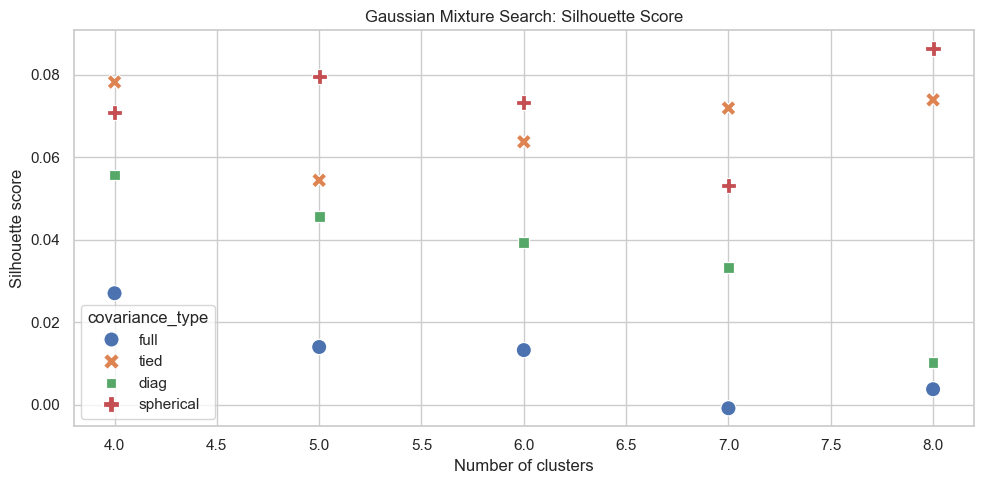

In [14]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=model_search_df, x='k', y='silhouette_score', hue='covariance_type', style='covariance_type', s=120)
plt.title('Gaussian Mixture Search: Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.show()


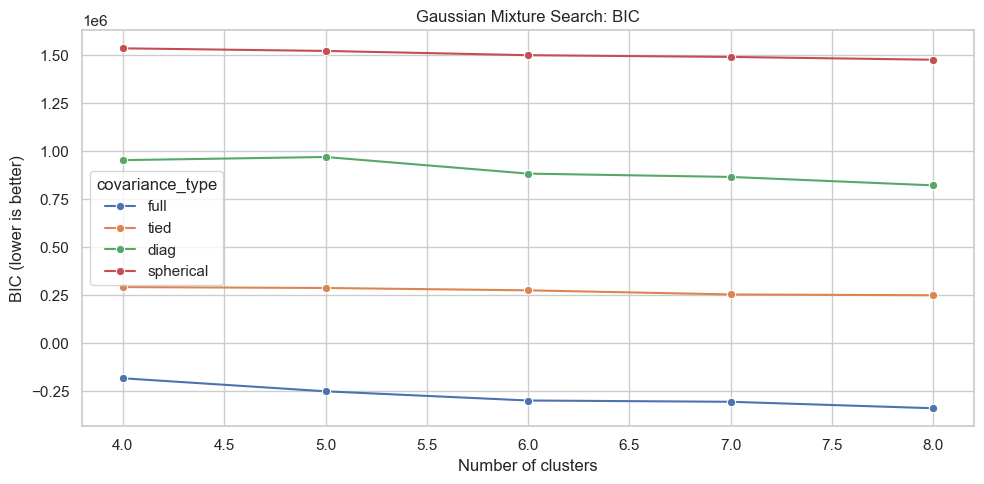

In [15]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=model_search_df, x='k', y='bic', hue='covariance_type', marker='o')
plt.title('Gaussian Mixture Search: BIC')
plt.xlabel('Number of clusters')
plt.ylabel('BIC (lower is better)')
plt.tight_layout()
plt.show()


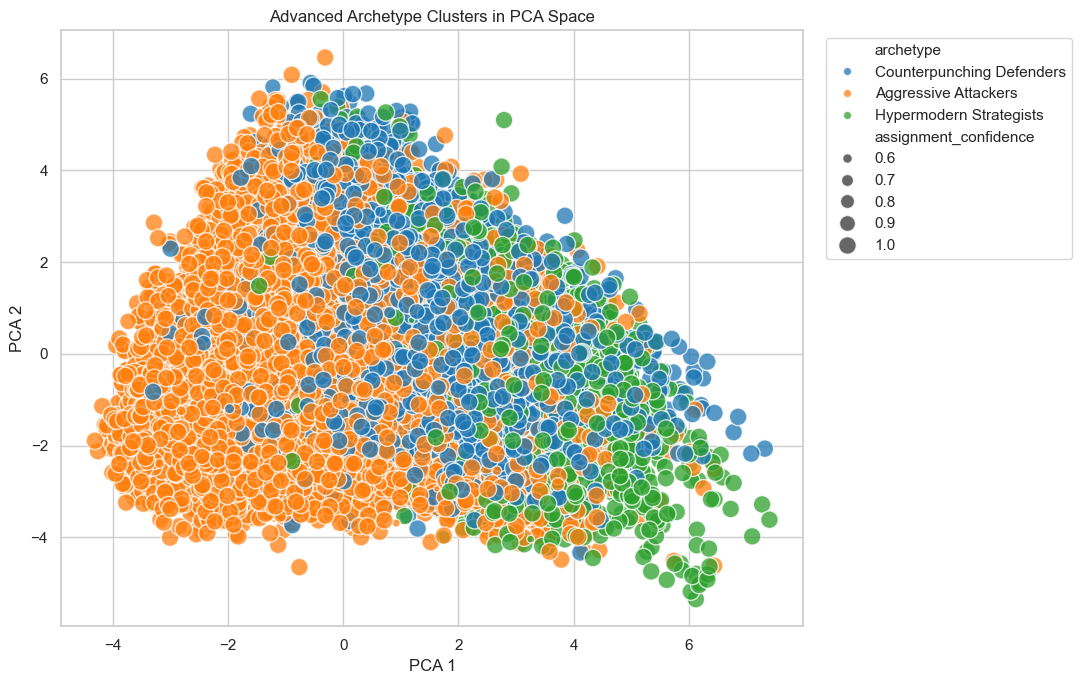

In [16]:
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=player_profiles,
    x='pca_1',
    y='pca_2',
    hue='archetype',
    size='assignment_confidence',
    sizes=(20, 160),
    alpha=0.75,
    palette='tab10',
)
plt.title('Advanced Archetype Clusters in PCA Space')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


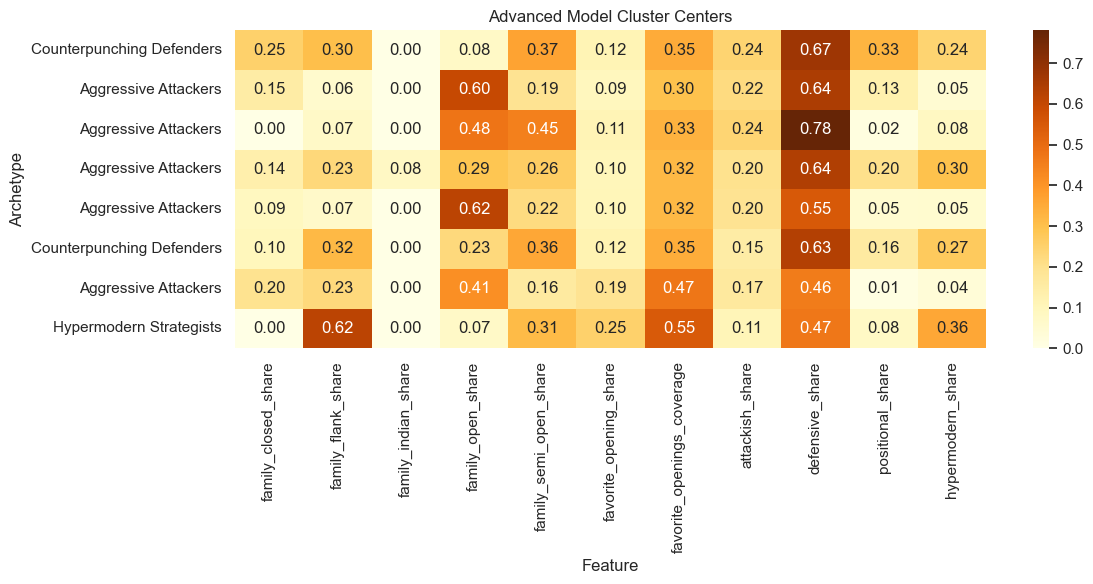

In [17]:
heatmap_cols = [
    'family_closed_share', 'family_flank_share', 'family_indian_share',
    'family_open_share', 'family_semi_open_share', 'favorite_opening_share',
    'favorite_openings_coverage', 'attackish_share', 'defensive_share',
    'positional_share', 'hypermodern_share'
]

heatmap_df = cluster_feature_means.sort_values('cluster_id').set_index('archetype')[heatmap_cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Advanced Model Cluster Centers')
plt.xlabel('Feature')
plt.ylabel('Archetype')
plt.tight_layout()
plt.show()


## Save Outputs


In [18]:
player_profiles.sort_values(['cluster_id', 'assignment_confidence'], ascending=[True, False]).to_csv(OUTPUT_DIR / 'advanced_player_archetypes.csv', index=False)
cluster_summary.to_csv(OUTPUT_DIR / 'advanced_cluster_summary.csv', index=False)
cluster_feature_means.sort_values('cluster_id').to_csv(OUTPUT_DIR / 'advanced_cluster_feature_means.csv', index=False)
model_search_df.to_csv(OUTPUT_DIR / 'advanced_model_search.csv', index=False)
top_openings_by_cluster.to_csv(OUTPUT_DIR / 'advanced_top_openings_by_cluster.csv', index=False)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=model_search_df, x='k', y='silhouette_score', hue='covariance_type', style='covariance_type', s=120)
plt.title('Gaussian Mixture Search: Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'advanced_silhouette_search.png', dpi=200)
plt.close()

plt.figure(figsize=(10, 5))
sns.lineplot(data=model_search_df, x='k', y='bic', hue='covariance_type', marker='o')
plt.title('Gaussian Mixture Search: BIC')
plt.xlabel('Number of clusters')
plt.ylabel('BIC (lower is better)')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'advanced_bic_search.png', dpi=200)
plt.close()

plt.figure(figsize=(11, 7))
sns.scatterplot(data=player_profiles, x='pca_1', y='pca_2', hue='archetype', size='assignment_confidence', sizes=(20, 160), alpha=0.75, palette='tab10')
plt.title('Advanced Archetype Clusters in PCA Space')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'advanced_player_archetypes_pca.png', dpi=200)
plt.close()

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrBr')
plt.title('Advanced Model Cluster Centers')
plt.xlabel('Feature')
plt.ylabel('Archetype')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'advanced_cluster_feature_heatmap.png', dpi=200)
plt.close()

print('Saved advanced outputs to:')
print(OUTPUT_DIR)
print(PLOT_DIR)


Saved advanced outputs to:
/Users/phamhoanghai/Ureca/Question_three/advanced_output
/Users/phamhoanghai/Ureca/Question_three/advanced_plots


In [19]:
cluster_summary


,cluster_id,archetype,players,mean_games,mean_elo,mean_opening_diversity,mean_favorite_share,mean_top5_coverage,mean_score,mean_confidence
0,2,Aggressive Attackers,2246,162.448798,1593.326647,64.606857,0.109750,0.333636,0.502923,0.986809
1,0,Counterpunching Defenders,2224,154.729766,1687.122231,60.416367,0.115082,0.349835,0.523538,0.988160
2,1,Aggressive Attackers,1947,147.690806,1584.930404,64.876733,0.093092,0.297741,0.492506,0.989537
3,5,Counterpunching Defenders,1490,248.427517,1614.566184,72.320805,0.121106,0.346036,0.480363,0.988711
4,6,Aggressive Attackers,1473,142.970129,1438.683810,43.822811,0.193276,0.473974,0.430092,0.987513
5,4,Aggressive Attackers,1340,108.882836,1468.332690,54.420896,0.103919,0.317777,0.459751,0.989059
6,3,Aggressive Attackers,1093,111.477585,1656.842183,54.531565,0.103327,0.317649,0.500786,0.994961
7,7,Hypermodern Strategists,1075,267.413953,1608.167148,54.093023,0.251288,0.546047,0.474393,0.994860
